In [12]:
import pandas as pd
import seaborn as sns
import streamlit as st
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [13]:
df=pd.read_csv('linear_regression_student_performance_1000_scaled.csv')

In [14]:
df.head()

,study_hours,attendance,assignment_score,previous_score,sleep_hours,practice_tests,exam_score
0,0.7744,0.0616,0.8428,0.8296,0.7160,0.3,0.4639
1,0.4386,0.4582,0.4459,0.5942,0.3566,0.2,0.3680
2,0.8592,0.1287,0.9532,0.2445,0.8520,0.5,0.4043
3,0.6976,0.1520,0.6506,0.7460,0.2403,0.7,0.4473
4,0.0931,0.6325,0.1150,0.0839,0.5381,0.2,0.0138


In [15]:
df.columns

Index(['study_hours', 'attendance', 'assignment_score', 'previous_score',
       'sleep_hours', 'practice_tests', 'exam_score'],
      dtype='object')

In [16]:
df.shape

(1000, 7)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   study_hours       1000 non-null   float64
 1   attendance        1000 non-null   float64
 2   assignment_score  1000 non-null   float64
 3   previous_score    1000 non-null   float64
 4   sleep_hours       1000 non-null   float64
 5   practice_tests    1000 non-null   float64
 6   exam_score        1000 non-null   float64
dtypes: float64(7)
memory usage: 54.8 KB


In [18]:
df.describe()

,study_hours,attendance,assignment_score,previous_score,sleep_hours,practice_tests,exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.497003,0.508536,0.492485,0.493539,0.485604,0.495800,0.367705
std,0.292206,0.289660,0.289927,0.290637,0.282204,0.318345,0.200428
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.239525,0.249275,0.244050,0.247375,0.241725,0.200000,0.227225
50%,0.494650,0.496500,0.495050,0.494500,0.478750,0.500000,0.369050
75%,0.759275,0.763350,0.745875,0.745700,0.726025,0.800000,0.503350
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [19]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='study_hours'>

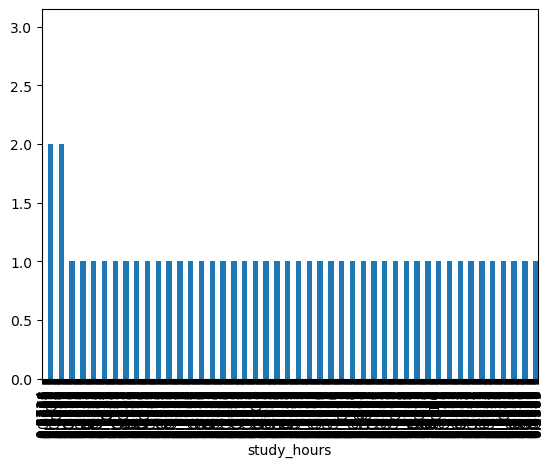

In [20]:
df['study_hours'].value_counts().plot(kind="bar")

In [21]:
df.isnull().sum()

study_hours         0
attendance          0
assignment_score    0
previous_score      0
sleep_hours         0
practice_tests      0
exam_score          0
dtype: int64

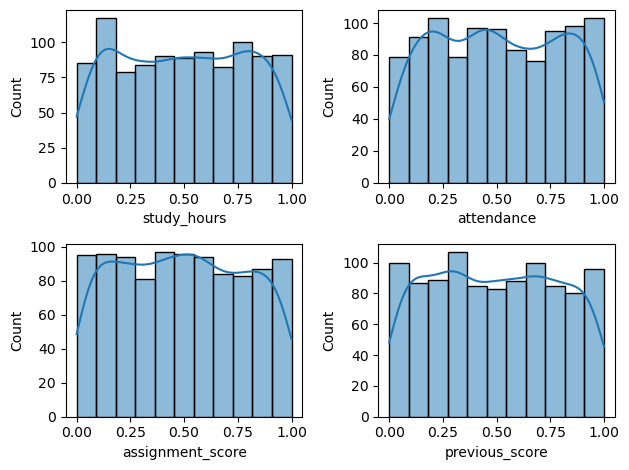

In [22]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)

plotting('study_hours',1)
plotting('attendance',2)
plotting('assignment_score',3)
plotting('previous_score',4)
plt.tight_layout()

In [23]:
X = df.drop('exam_score', axis=1)
y = df['exam_score']

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
y_pred=model.predict(X_test)

In [28]:
y_pred

array([ 0.56558463,  0.40141843,  0.00997713,  0.24930095,  0.4390949 ,
        0.38530754,  0.55945888,  0.50782595,  0.1021297 ,  0.49298222,
        0.28462008,  0.44489365,  0.47216496,  0.38459753,  0.26907618,
        0.09836372,  0.34865969,  0.37055735,  0.29672523,  0.51812068,
        0.39975153,  0.41696871,  0.20427418,  0.3828511 ,  0.5251841 ,
        0.23580095,  0.08321749,  0.05725323,  0.38567349,  0.40011206,
        0.65948364,  0.44118177,  0.42004294,  0.60260754,  0.43555768,
        0.07353061,  0.66923318,  0.47604589,  0.48052001,  0.14141913,
        0.36276007, -0.01848286,  0.34707723,  0.10057005,  0.19962842,
        0.20028853, -0.01224906,  0.1946102 ,  0.59937763,  0.07204018,
        0.31850662,  0.18267228,  0.61091105,  0.52012258,  0.37632319,
        0.37394093,  0.31787479,  0.17032355,  0.39630286,  0.53203222,
        0.49294958,  0.33737778,  0.51485821,  0.05050683,  0.41701519,
        0.22790216,  0.55614461,  0.49345349,  0.31302931,  0.13

In [29]:
y_test

521    0.5632
737    0.3699
740    0.0000
660    0.2773
411    0.4657
        ...  
506    0.6492
342    0.2895
485    0.4055
711    0.2946
133    0.3044
Name: exam_score, Length: 330, dtype: float64

In [30]:
from sklearn.metrics import r2_score

In [33]:
r2=r2_score(y_test,y_pred)
r2

0.774651208784819

In [34]:
n=X_test.shape[0]
p=X_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
adjusted_r2

0.770465163127571